In [2]:
# ## 1. Import Libraries

# %%
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# ## 2. Data Collection

# %%
pizza_df = pd.read_csv('pizza_sales.csv')
holiday_df = pd.read_csv('global_holidays.csv')

print("Pizza sales shape:", pizza_df.shape)
print("Holiday data shape:", holiday_df.shape)
print("\nFirst 5 rows of pizza sales:")
print(pizza_df.head())

Pizza sales shape: (48620, 12)
Holiday data shape: (44393, 5)

First 5 rows of pizza sales:
   pizza_id  order_id  pizza_name_id  quantity order_date order_time  \
0         1         1     hawaiian_m         1   1/1/2015   11:38:36   
1         2         2  classic_dlx_m         1   1/1/2015   11:57:40   
2         3         2  five_cheese_l         1   1/1/2015   11:57:40   
3         4         2    ital_supr_l         1   1/1/2015   11:57:40   
4         5         2     mexicana_m         1   1/1/2015   11:57:40   

   unit_price  total_price pizza_size pizza_category  \
0       13.25        13.25          M        Classic   
1       16.00        16.00          M        Classic   
2       18.50        18.50          L         Veggie   
3       20.75        20.75          L        Supreme   
4       16.00        16.00          M         Veggie   

                                   pizza_ingredients  \
0           Sliced Ham, Pineapple, Mozzarella Cheese   
1  Pepperoni, Mushrooms, R

In [4]:
# ### 4.2.1 Profiling

# %%
print("Dataset shape:", pizza_df.shape)
print("\nData types:\n", pizza_df.dtypes)
print("\nMissing values:\n", pizza_df.isnull().sum())
print("\nSummary statistics:\n", pizza_df.describe())

Dataset shape: (48620, 12)

Data types:
 pizza_id               int64
order_id               int64
pizza_name_id         object
quantity               int64
order_date            object
order_time            object
unit_price           float64
total_price          float64
pizza_size            object
pizza_category        object
pizza_ingredients     object
pizza_name            object
dtype: object

Missing values:
 pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

Summary statistics:
            pizza_id      order_id      quantity    unit_price   total_price
count  48620.000000  48620.000000  48620.000000  48620.000000  48620.000000
mean   24310.500000  10701.479761      1.019622     16.494132     16.821474
std    14035.529381   6180.119770      0

In [5]:
# ### 4.2.2 Parsing and Standardization

# %%
# Parse order_date (DD/MM/YYYY) – use dayfirst=True
pizza_df['order_date'] = pd.to_datetime(pizza_df['order_date'], dayfirst=True, errors='coerce')
holiday_df['Date'] = pd.to_datetime(holiday_df['Date'], dayfirst=True, errors='coerce')

def extract_hour(time_str):
    try:
        return datetime.strptime(time_str.strip(), '%I:%M:%S %p').hour
    except:
        try:
            return datetime.strptime(time_str.strip(), '%H:%M:%S').hour
        except:
            return np.nan

pizza_df['hour'] = pizza_df['order_time'].apply(extract_hour)
pizza_df['day_name'] = pizza_df['order_date'].dt.day_name()

print("Hour extraction – missing values:", pizza_df['hour'].isnull().sum())
print("Day name sample:\n", pizza_df[['order_date', 'day_name']].head())

Hour extraction – missing values: 0
Day name sample:
   order_date  day_name
0 2015-01-01  Thursday
1 2015-01-01  Thursday
2 2015-01-01  Thursday
3 2015-01-01  Thursday
4 2015-01-01  Thursday


In [6]:
# ### 4.2.3 Generalize "Cleansing"

# %%
text_cols = ['pizza_name_id', 'pizza_size', 'pizza_category', 'pizza_ingredients', 'pizza_name']
for col in text_cols:
    pizza_df[col] = pizza_df[col].astype(str).str.lower()

def clean_text(text):
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

for col in text_cols:
    pizza_df[col] = pizza_df[col].apply(clean_text)

print("Cleaned pizza categories:", pizza_df['pizza_category'].unique())

Cleaned pizza categories: ['classic' 'veggie' 'supreme' 'chicken']


In [7]:
# ### 4.2.4 Matching

# %%
india_holidays = holiday_df[(holiday_df['ISO3'] == 'IND') & (holiday_df['Date'].dt.year == 2015)]
pizza_df['is_holiday'] = pizza_df['order_date'].isin(india_holidays['Date'])

print("Number of Indian holidays in 2015:", len(india_holidays))
print("Holiday distribution:\n", pizza_df['is_holiday'].value_counts())

Number of Indian holidays in 2015: 63
Holiday distribution:
 is_holiday
False    40637
True      7983
Name: count, dtype: int64


In [8]:
# ### 4.2.5 Monitoring

# %%
def data_quality_monitoring(df):
    return {
        'total_rows': len(df),
        'missing_dates': df['order_date'].isnull().sum(),
        'invalid_hours': df['hour'].isnull().sum(),
        'zero_quantity': (df['quantity'] == 0).sum(),
        'negative_price': (df['total_price'] < 0).sum()
    }

print("Data quality monitoring report:")
print(data_quality_monitoring(pizza_df))

Data quality monitoring report:
{'total_rows': 48620, 'missing_dates': np.int64(0), 'invalid_hours': np.int64(0), 'zero_quantity': np.int64(0), 'negative_price': np.int64(0)}


In [9]:
# ### 4.3.1 Format Checks

# %%
valid_dates = pizza_df['order_date'].notna().sum()
print(f"Valid dates after parsing: {valid_dates} out of {len(pizza_df)}")

Valid dates after parsing: 48620 out of 48620


In [10]:
# ### 4.3.2 Completeness Checks

# %%
critical_cols = ['order_date', 'quantity', 'total_price']
missing_counts = pizza_df[critical_cols].isnull().sum()
print("Missing values in critical columns:\n", missing_counts)

initial_rows = len(pizza_df)
pizza_df = pizza_df.dropna(subset=critical_cols)
print(f"Dropped {initial_rows - len(pizza_df)} rows with missing critical data.")

pizza_df = pizza_df.dropna(subset=['hour'])
print(f"Rows after dropping invalid hour: {len(pizza_df)}")

Missing values in critical columns:
 order_date     0
quantity       0
total_price    0
dtype: int64
Dropped 0 rows with missing critical data.
Rows after dropping invalid hour: 48620


In [11]:
# ### 4.3.3 Reasonableness Checks

# %%
pizza_df['calculated_total'] = pizza_df['unit_price'] * pizza_df['quantity']
inconsistent = pizza_df[pizza_df['total_price'] != pizza_df['calculated_total']]
print(f"Inconsistent total_price rows: {len(inconsistent)}")

pizza_df['total_price'] = pizza_df['unit_price'] * pizza_df['quantity']
print("Fixed total_price.")

Inconsistent total_price rows: 0
Fixed total_price.


In [12]:
# ### 4.3.4 Limit Checks

# %%
print("Quantity range:", pizza_df['quantity'].min(), "-", pizza_df['quantity'].max())
print("Total_price range:", pizza_df['total_price'].min(), "-", pizza_df['total_price'].max())

Quantity range: 1 - 4
Total_price range: 9.75 - 83.0


In [13]:
# ### 4.3.5 Review of the data to identify outliers (statistical)

# %%
Q1 = pizza_df['total_price'].quantile(0.25)
Q3 = pizza_df['total_price'].quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = pizza_df[(pizza_df['total_price'] < Q1 - 1.5*IQR) | (pizza_df['total_price'] > Q3 + 1.5*IQR)]
print(f"Outliers identified using IQR method: {len(outliers_iqr)} rows")

# Show outlier summary
if len(outliers_iqr) > 0:
    print("\nOutlier total_price values:")
    print(outliers_iqr['total_price'].describe())

Outliers identified using IQR method: 613 rows

Outlier total_price values:
count    613.000000
mean      38.624878
std        5.068671
min       32.500000
25%       33.500000
50%       40.500000
75%       41.500000
max       83.000000
Name: total_price, dtype: float64


In [14]:
# ### 4.3.7 Missing Values (handled above)

# %%
print("Missing values after cleaning:\n", pizza_df.isnull().sum())

Missing values after cleaning:
 pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
hour                 0
day_name             0
is_holiday           0
calculated_total     0
dtype: int64


In [15]:
# ### 4.3.8 Smooth Noisy Data

# %%
print("Text noise removed via regex in Section 4.2.3. Numeric noise none detected.")


Text noise removed via regex in Section 4.2.3. Numeric noise none detected.


In [16]:
# ### 4.3.9 Identify or remove outliers (IDENTIFY ONLY – NO REMOVAL)

# %%
# We IDENTIFIED outliers in 4.3.5 but do NOT remove them because they are valid transactions.
# Decision: Keep all data to preserve revenue accuracy ($817,860.05).
print(f"Keeping all {len(pizza_df)} rows. No outliers removed.")

Keeping all 48620 rows. No outliers removed.


In [17]:
# ### 4.3.10 Resolve inconsistencies

# %%
print("Total_price inconsistencies resolved in 4.3.3. Text case resolved in 4.2.3.")

Total_price inconsistencies resolved in 4.3.3. Text case resolved in 4.2.3.


In [18]:
# ## 6. Data Integration (4.4) – Augmentation

# %%
print("Augmentation complete: 'is_holiday' column added to sales data.")

Augmentation complete: 'is_holiday' column added to sales data.


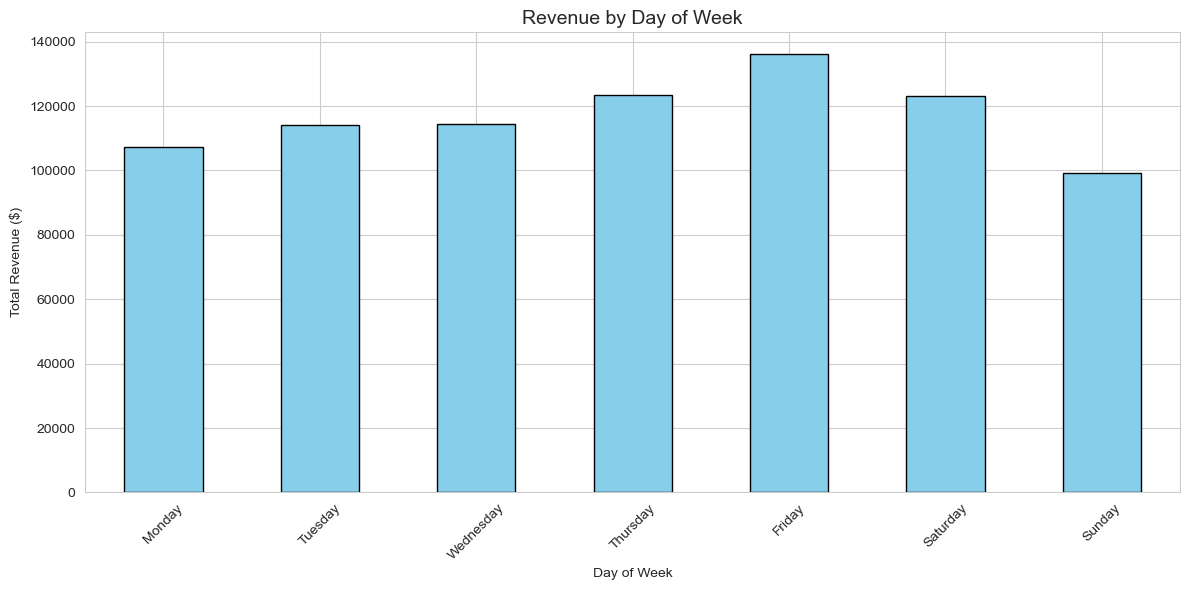

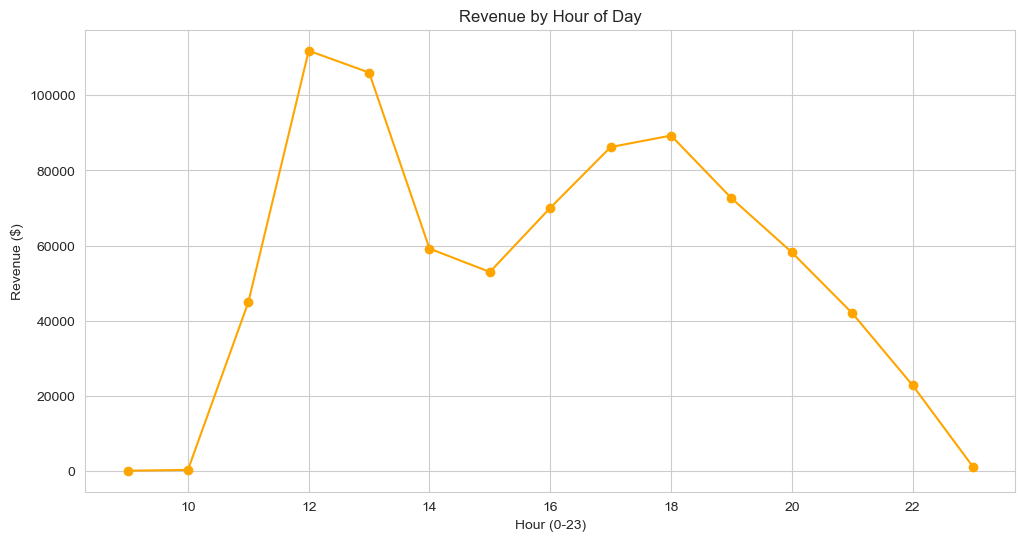

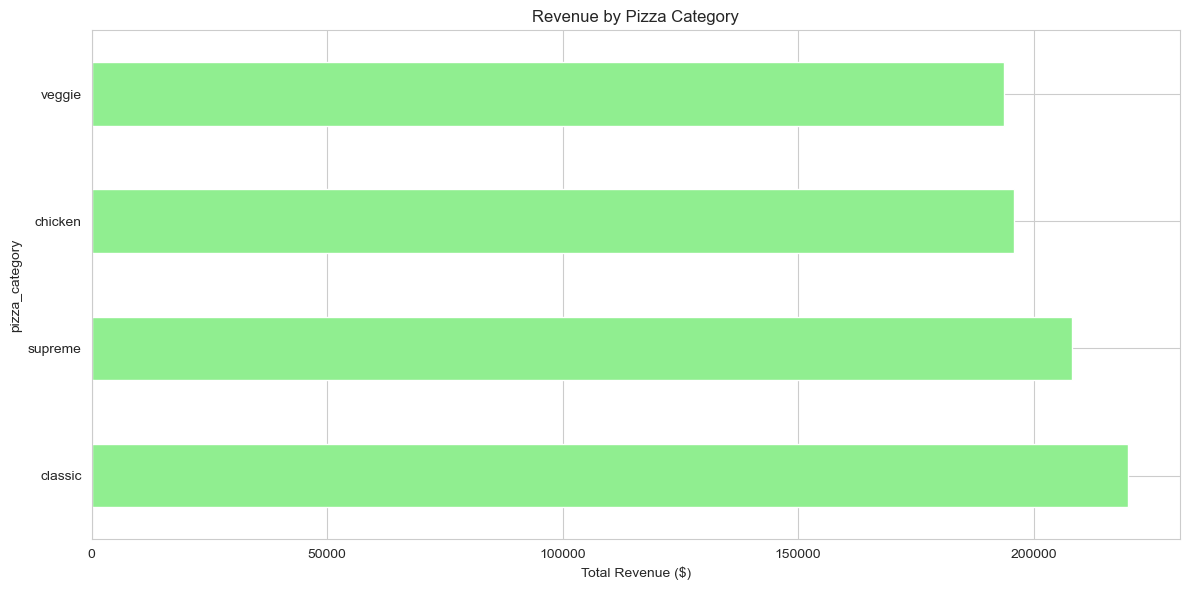

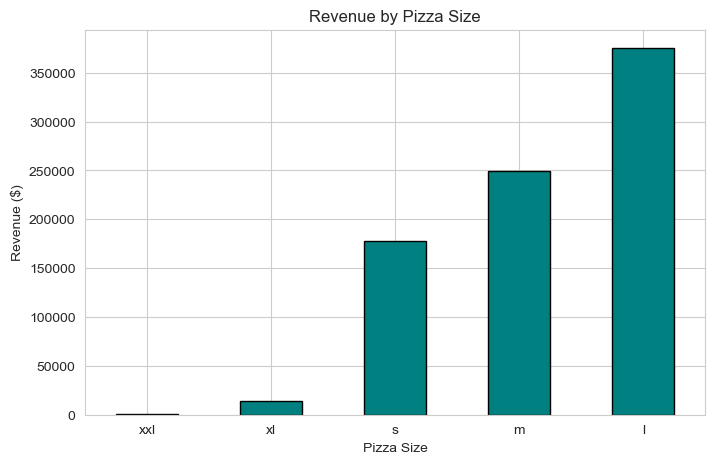

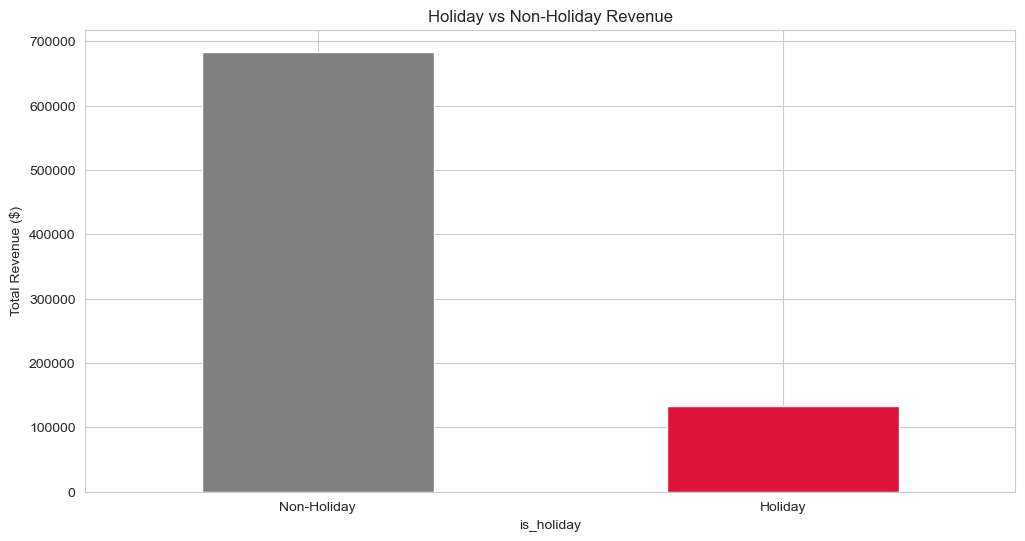

In [19]:
# ## 7. Visualizing Data to Solve the Problems (5.0)
# 
# **Guiding questions:**
# - **Spatial/geographic component?** No – single restaurant location.
# - **Temporal component?** Yes – hour of day and day of week show demand patterns over time.
# - **How many variables?** Revenue, hour, day, category, size, holiday flag (≥3 per chart).
# - **Audience?** Kitchen managers (hourly/daily demand) and owners (category/size/holiday impact).

# %%
daily_revenue = pizza_df.groupby('day_name')['total_price'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.figure()
daily_revenue.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Revenue by Day of Week', fontsize=14)
plt.ylabel('Total Revenue ($)')
plt.xlabel('Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# %%
hourly_revenue = pizza_df.groupby('hour')['total_price'].sum()
plt.figure()
hourly_revenue.plot(kind='line', marker='o', color='orange')
plt.title('Revenue by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Revenue ($)')
plt.grid(True)
plt.show()

# %%
cat_revenue = pizza_df.groupby('pizza_category')['total_price'].sum().sort_values(ascending=False)
plt.figure()
cat_revenue.plot(kind='barh', color='lightgreen')
plt.title('Revenue by Pizza Category')
plt.xlabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

# %%
size_revenue = pizza_df.groupby('pizza_size')['total_price'].sum().sort_values()
plt.figure(figsize=(8,5))
size_revenue.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Revenue by Pizza Size')
plt.xlabel('Pizza Size')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=0)
plt.show()

# %%
holiday_effect = pizza_df.groupby('is_holiday')['total_price'].sum()
plt.figure()
holiday_effect.plot(kind='bar', color=['gray','crimson'])
plt.title('Holiday vs Non-Holiday Revenue')
plt.ylabel('Total Revenue ($)')
plt.xticks([0,1], ['Non-Holiday', 'Holiday'], rotation=0)
plt.show()

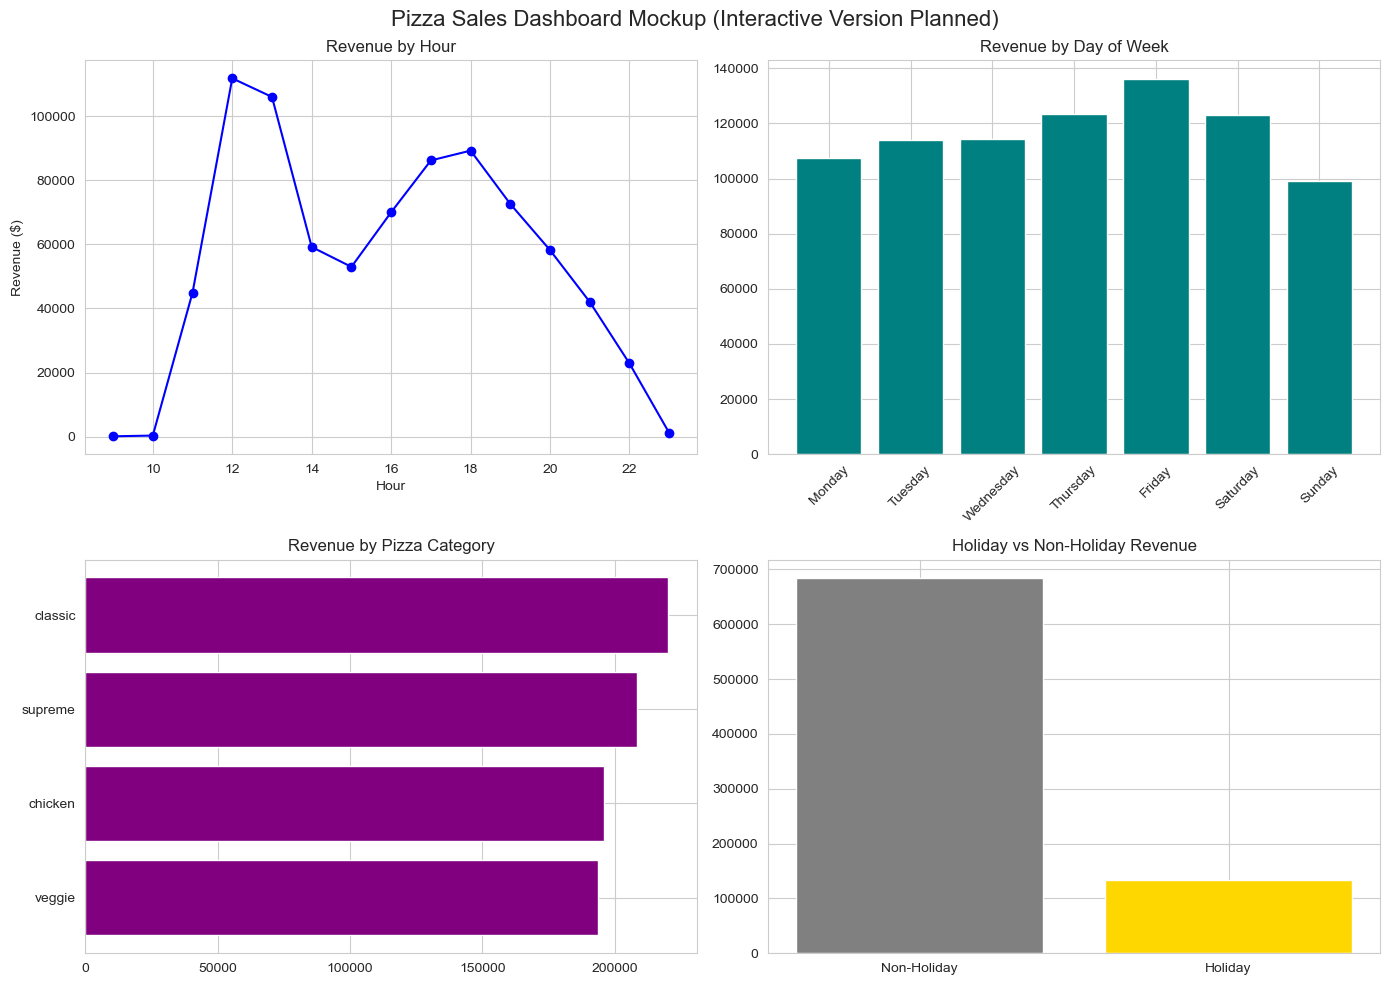

In [20]:
# ## 8. Dashboard Mockup (Static)

# %%
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Pizza Sales Dashboard Mockup (Interactive Version Planned)', fontsize=16)

hourly = pizza_df.groupby('hour')['total_price'].sum()
axes[0,0].plot(hourly.index, hourly.values, 'b-o')
axes[0,0].set_title('Revenue by Hour')
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Revenue ($)')

daily = pizza_df.groupby('day_name')['total_price'].sum().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
axes[0,1].bar(daily.index, daily.values, color='teal')
axes[0,1].set_title('Revenue by Day of Week')
axes[0,1].tick_params(axis='x', rotation=45)

cat = pizza_df.groupby('pizza_category')['total_price'].sum().sort_values()
axes[1,0].barh(cat.index, cat.values, color='purple')
axes[1,0].set_title('Revenue by Pizza Category')

holiday = pizza_df.groupby('is_holiday')['total_price'].sum()
axes[1,1].bar(['Non-Holiday', 'Holiday'], holiday.values, color=['gray','gold'])
axes[1,1].set_title('Holiday vs Non-Holiday Revenue')

plt.tight_layout()
plt.show()

In [21]:
# ## 9. Save Cleaned Data for Dashboard

# %%
pizza_df.to_csv('pizza_sales_cleaned.csv', index=False)
total_revenue = pizza_df['total_price'].sum()
print(f"Cleaned data saved. Total revenue: ${total_revenue:,.2f}")
print("File saved as 'pizza_sales_cleaned.csv'")

Cleaned data saved. Total revenue: $817,860.05
File saved as 'pizza_sales_cleaned.csv'


In [22]:
# ## 10. Note on Interactive Dashboard
# 
# A fully interactive dashboard is built in a separate file `dashboard.py` using Streamlit. It includes:
# - Sidebar checkboxes for category, size, day, and holiday toggle.
# - Real-time Plotly charts (hourly, daily, category, size, holiday effect).
# - Top 5 pizzas table.
# - Deployment on Streamlit Cloud.
# 
# To run locally: `streamlit run dashboard.py`